# Derivatives and Their Notation

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **derivative notation**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- the two standard ways to write a derivative: **Leibniz** and **Lagrange** notation
- how $\dfrac{\Delta x}{\Delta t}$ (secant slope) becomes $\dfrac{dx}{dt}$ (tangent slope)
- the meaning of the infinitesimals $dx, dt$ and of $\dfrac{d}{dx}$ as an **operator**
- writing the same derivative both ways, demonstrated with SymPy

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Slopes, Maxima and Minima*.

## 1. Introduction

> *"Like any language, mathematics has its way of expressing concepts. There are two ways to
> express the derivative: Leibniz notation and Lagrange notation."*

Both describe the same thing — the slope of the tangent line — but each is convenient in
different situations, so the course uses both.

## 2. From secant to tangent

The slope over an interval is the **secant** slope

$$
\frac{\Delta x}{\Delta t} = \frac{\text{change in distance}}{\text{change in time}}.
$$

Shrinking the interval ($\Delta t \to 0$), the secant slopes approach the **tangent** slope,
written

$$
\frac{dx}{dt} = \lim_{\Delta t \to 0} \frac{\Delta x}{\Delta t}.
$$

Here $dx$ and $dt$ are **infinitesimal** changes — vanishingly small steps in the $x$ and
$t$ directions.

## 3. General axes: $\dfrac{dy}{dx}$

Usually we put the input on the horizontal axis $x$ and the output on the vertical axis
$y$, with $y = f(x)$. Then the derivative is written $\dfrac{dy}{dx}$.

### The two notations

For $y = f(x)$, the derivative can be written:

- **Lagrange notation:** $f'(x)$ — "the function $f$, primed, at $x$".
- **Leibniz notation:** $\dfrac{dy}{dx}$, also written $\dfrac{d}{dx} f(x)$.

In Leibniz form, $\dfrac{d}{dx}$ is an **operator** — something you *apply* to $f(x)$ to get
its derivative.

$$
f'(x) \;=\; \frac{dy}{dx} \;=\; \frac{d}{dx} f(x).
$$

## 4. The same derivative, both ways (SymPy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
f = x**2

# Leibniz operator form, shown unevaluated then evaluated
op = sp.Derivative(f, x)
print("Leibniz (operator):", op, "=", op.doit())   # d/dx (x**2) = 2*x

# the result is the same object however you name it
fprime = sp.diff(f, x)
print("Lagrange f'(x)    :", fprime)
print("Leibniz  dy/dx    :", fprime, "  (identical result)")

Leibniz (operator): Derivative(x**2, x) = 2*x
Lagrange f'(x)    : 2*x
Leibniz  dy/dx    : 2*x   (identical result)


### A small dictionary

The two notations always give the same derivative — only the *writing* differs.

In [2]:
funcs = [x**2, x**3, sp.sin(x), sp.exp(x), sp.log(x)]

print(f"{'f(x)':>10} | {'Lagrange':>16} | {'Leibniz':>18}")
print("-" * 52)
for fn in funcs:
    d = sp.diff(fn, x)
    print(f"{str(fn):>10} | {str(d):>16} | {str(d):>18}")

      f(x) |         Lagrange |            Leibniz
----------------------------------------------------
      x**2 |              2*x |                2*x
      x**3 |           3*x**2 |             3*x**2
    sin(x) |           cos(x) |             cos(x)
    exp(x) |           exp(x) |             exp(x)
    log(x) |              1/x |                1/x


## 5. Higher derivatives

The notations extend to repeated differentiation:

- **Lagrange:** $f''(x), f'''(x), \dots$
- **Leibniz:** $\dfrac{d^2 y}{dx^2}, \dfrac{d^3 y}{dx^3}, \dots$

In [3]:
f = x**4
print("f(x)      =", f)
print("f'(x)     =", sp.diff(f, x),    "   (Leibniz dy/dx)")
print("f''(x)    =", sp.diff(f, x, 2), "   (Leibniz d²y/dx²)")
print("f'''(x)   =", sp.diff(f, x, 3), "   (Leibniz d³y/dx³)")

f(x)      = x**4
f'(x)     = 4*x**3    (Leibniz dy/dx)
f''(x)    = 12*x**2    (Leibniz d²y/dx²)
f'''(x)   = 24*x    (Leibniz d³y/dx³)


## 6. Picturing the notation

At a point, $f'(x)$ and $\dfrac{dy}{dx}$ both name the **slope of the tangent line** — the
ratio of a tiny rise $dy$ to a tiny run $dx$.

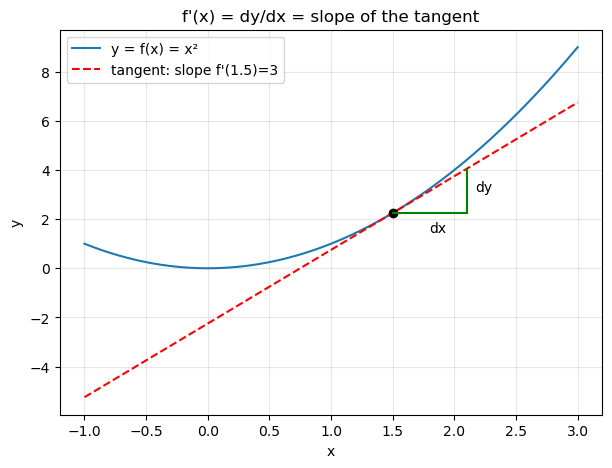

In [4]:
xs = np.linspace(-1, 3, 200)
fnum = lambda t: t**2
x0 = 1.5
slope = 2*x0     # f'(1.5) = 3

plt.figure(figsize=(7, 5))
plt.plot(xs, fnum(xs), label="y = f(x) = x²")
plt.plot(xs, fnum(x0) + slope*(xs - x0), "r--", label=f"tangent: slope f'({x0})={slope:.0f}")
plt.plot(x0, fnum(x0), "ko")
# little dx, dy triangle
dx = 0.6
plt.plot([x0, x0+dx], [fnum(x0), fnum(x0)], "g")
plt.plot([x0+dx, x0+dx], [fnum(x0), fnum(x0)+slope*dx], "g")
plt.annotate("dx", (x0+dx/2, fnum(x0)), textcoords="offset points", xytext=(0, -14))
plt.annotate("dy", (x0+dx, fnum(x0)+slope*dx/2), textcoords="offset points", xytext=(6, 0))
plt.title("f'(x) = dy/dx = slope of the tangent")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 7. Exercises

### Basic
1. Write the derivative of $y = f(x)$ in both Lagrange and Leibniz notation.
2. What does the operator $\dfrac{d}{dx}$ do?

### Intermediate
3. Write the derivative of $f(x) = x^3$ in both notations.
4. Write the **second** derivative of $y = x^5$ in both notations.

### Advanced
5. Using SymPy, show the unevaluated Leibniz form $\dfrac{d}{dx}\sin(x)$ and then evaluate it.
6. Explain why $\dfrac{dy}{dx}$ and $f'(x)$ always give the same result for $y = f(x)$.

## 8. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 3.
print("3. f(x)=x³:  Lagrange f'(x) =", sp.diff(x**3, x), ";  Leibniz d/dx f(x) =", sp.diff(x**3, x))
# 4.
print("4. y=x⁵:  Lagrange f''(x) =", sp.diff(x**5, x, 2), ";  Leibniz d²y/dx² =", sp.diff(x**5, x, 2))
# 5.
op = sp.Derivative(sp.sin(x), x)
print("5. unevaluated:", op, " -> evaluated:", op.doit())

print("1. Lagrange: f'(x);  Leibniz: dy/dx (or d/dx f(x)).")
print("2. It takes a function and returns its derivative (a differentiation operator).")
print("6. They are two names for the same quantity — the slope of the tangent of y=f(x).")

3. f(x)=x³:  Lagrange f'(x) = 3*x**2 ;  Leibniz d/dx f(x) = 3*x**2
4. y=x⁵:  Lagrange f''(x) = 20*x**3 ;  Leibniz d²y/dx² = 20*x**3
5. unevaluated: Derivative(sin(x), x)  -> evaluated: cos(x)
1. Lagrange: f'(x);  Leibniz: dy/dx (or d/dx f(x)).
2. It takes a function and returns its derivative (a differentiation operator).
6. They are two names for the same quantity — the slope of the tangent of y=f(x).


## 9. Conclusion

- The derivative has two standard notations, both meaning the **slope of the tangent**:
  - **Lagrange:** $f'(x)$,
  - **Leibniz:** $\dfrac{dy}{dx} = \dfrac{d}{dx} f(x)$, where $\dfrac{d}{dx}$ is an
    operator.
- They come from the limit of the secant slope $\dfrac{\Delta x}{\Delta t} \to \dfrac{dx}{dt}$,
  with $dx, dt$ infinitesimal changes.
- Higher derivatives follow the same pattern ($f''$ vs $\frac{d^2y}{dx^2}$).
- This course freely switches between the two, choosing whichever is more convenient.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (6).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture on **derivatives and their notation**. Key spoken points, lightly
cleaned:

> Mathematics has ways to express concepts; there are two notations for the derivative,
> Leibniz and Lagrange. The slope is the change in distance over change in time,
> $\Delta x/\Delta t$; the slope of the tangent is $dx/dt$, obtained by shrinking the
> interval until it's so tiny you get the tangent line, where $dx$ and $dt$ are
> infinitesimal changes. In general, with $x$ horizontal and $y$ vertical, the derivative is
> $dy/dx$. If $y = f(x)$, the derivative is written either as $f'(x)$ (Lagrange) or as
> $dy/dx = \frac{d}{dx} f(x)$ (Leibniz), where $\frac{d}{dx}$ is an operator you apply to
> $f(x)$. The course uses whichever notation is more convenient.